In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r"C:\Users\Надежда\Downloads\UNZIP_ME_FOR_NOTEBOOKS_ML_RUS_V14\08-Linear-Regression-Models\Advertising.csv")

In [3]:
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [4]:
X = df.drop('sales', axis=1)
y = df['sales']

In [5]:
from sklearn.preprocessing import PolynomialFeatures

In [6]:
polynomial_converter = PolynomialFeatures(degree=3, include_bias=False)

In [7]:
poly_features = polynomial_converter.fit_transform(X)

In [9]:
poly_features.shape

(200, 19)

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(poly_features,y, test_size=0.3, random_state=101)

In [12]:
X_train.shape

(140, 19)

In [13]:
from sklearn.preprocessing import StandardScaler

In [14]:
scaler = StandardScaler()

In [15]:
scaler.fit(X_train)

StandardScaler()

In [16]:
X_train = scaler.transform(X_train)

In [17]:
X_test = scaler.transform(X_test)

In [18]:
X_train[0]

array([ 0.49300171, -0.33994238,  1.61586707,  0.28407363, -0.02568776,
        1.49677566, -0.59023161,  0.41659155,  1.6137853 ,  0.08057172,
       -0.05392229,  1.01524393, -0.36986163,  0.52457967,  1.48737034,
       -0.66096022, -0.16360242,  0.54694754,  1.37075536])

In [19]:
poly_features[0]

array([2.30100000e+02, 3.78000000e+01, 6.92000000e+01, 5.29460100e+04,
       8.69778000e+03, 1.59229200e+04, 1.42884000e+03, 2.61576000e+03,
       4.78864000e+03, 1.21828769e+07, 2.00135918e+06, 3.66386389e+06,
       3.28776084e+05, 6.01886376e+05, 1.10186606e+06, 5.40101520e+04,
       9.88757280e+04, 1.81010592e+05, 3.31373888e+05])

In [20]:
from sklearn.linear_model import Ridge

In [22]:
ridge_model = Ridge(alpha=10)

ridge_model.fit(X_train, y_train)

In [24]:
test_predictions = ridge_model.predict(X_test)

In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [26]:
MAE = mean_absolute_error(y_test, test_predictions)

In [27]:
MSE = mean_squared_error(y_test, test_predictions)

In [28]:
RMSE = np.sqrt(MSE)

In [29]:
print(MAE, MSE, RMSE, sep='\n')

0.5774404204714166
0.8003783071528348
0.8946386461319648


Насколько alpha=10 хорошее значение?

Вывод: сравнить его с другими значениями alpha с помощью кросс-валидации

In [31]:
from sklearn.linear_model import RidgeCV

CV = cross-validation

In [41]:
ridge_cv_model = RidgeCV(alphas=(0.1, 1.0, 10.0), scoring='neg_mean_absolute_error')
# scorers - по какой метрике будут выбиратсья наилучшие результаты

In [42]:
ridge_cv_model.fit(X_train, y_train)

RidgeCV(scoring='neg_mean_absolute_error')

X_test, y_test - "hold-out test set". X_train, y_train методом будут разбиты на train и validation части

In [43]:
ridge_cv_model.alpha_
# the best alpha

np.float64(0.1)

In [37]:
from sklearn.metrics import get_scorer_names

In [44]:
#get_scorer_names()
# the higer the value the better.
# Именно поэтому MSE здесь со знаком "-" - neg_mean_absolute_error - чтобы соблюсти логику программы

При желании можно попробовать значения alpha около 0,1. И даже 0, вдруг обычная лин.регрессия будет работать даже лучше

In [45]:
test_predictions = ridge_cv_model.predict(X_test)

In [46]:
MAE = mean_absolute_error(y_test, test_predictions)

In [47]:
MSE = mean_squared_error(y_test, test_predictions)

In [48]:
RMSE = np.sqrt(MSE)

In [49]:
print(MAE, MSE, RMSE, sep='\n')

0.42737748843375084
0.38201298815109863
0.6180719926926787


In [51]:
ridge_cv_model.coef_
#все коэффициенты не равны 0

array([ 5.40769392,  0.5885865 ,  0.40390395, -6.18263924,  4.59607939,
       -1.18789654, -1.15200458,  0.57837796, -0.1261586 ,  2.5569777 ,
       -1.38900471,  0.86059434,  0.72219553, -0.26129256,  0.17870787,
        0.44353612, -0.21362436, -0.04622473, -0.06441449])

In [53]:
ridge_cv_model.best_score_
# the best "scoring" value
# in our case it is the value of neg_mean_absolute_error

-0.3749223340292961

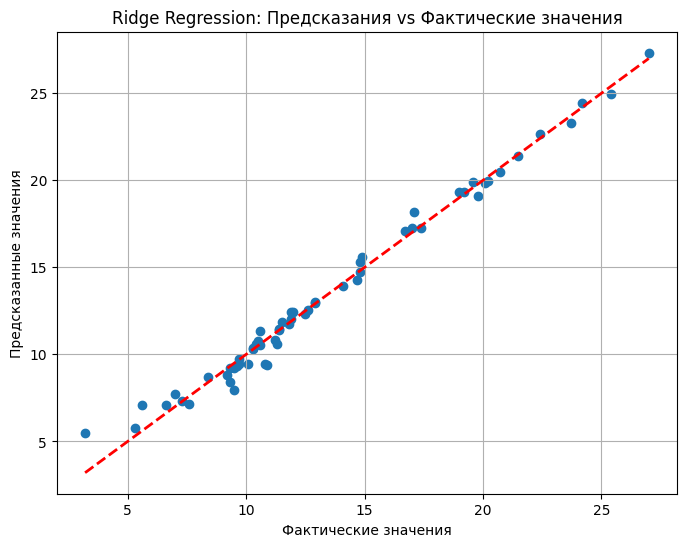

In [56]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, test_predictions)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)  # Идеальная линия
plt.xlabel('Фактические значения')
plt.ylabel('Предсказанные значения')
plt.title('Ridge Regression: Предсказания vs Фактические значения')
plt.grid(True)
plt.show()

#### **LASSO - Least Absolute Shrinkage and Selection Operator**

In [58]:
from sklearn.linear_model import LassoCV

In [75]:
lasso_cv_model = LassoCV(eps=0.01, n_alphas=100, cv=5, max_iter=1000000)

In [76]:
lasso_cv_model.fit(X_train,y_train)

LassoCV(cv=5, eps=0.01, max_iter=1000000)

In [77]:
lasso_cv_model.alpha_

np.float64(0.049430709092258315)

In [78]:
test_predictions = lasso_cv_model.predict(X_test)

In [79]:
MAE = mean_absolute_error(y_test, test_predictions)

In [80]:
RMSE = np.sqrt(mean_squared_error(y_test, test_predictions))

In [81]:
MAE

0.5159788188265405

In [82]:
RMSE

np.float64(0.7615440303260838)

In [83]:
lasso_cv_model.coef_

array([ 2.35600233,  0.21183181,  0.        , -0.        ,  3.78675114,
       -0.        ,  0.        ,  0.0624318 ,  0.        , -1.01152151,
       -0.        , -0.        ,  0.        ,  0.        , -0.        ,
        0.        ,  0.        ,  0.        ,  0.        ])

L1 VS L2 :

Более простая модель (нек-ые коэфф-ы равны 0) VS более высокая точность

### **Elastic Net**

In [84]:
from sklearn.linear_model import ElasticNetCV

In [85]:
elastic_model = ElasticNetCV(l1_ratio=[.1, .5, .7, .9, .95, .99, 1], 
                             eps=0.01, n_alphas=100, max_iter=1000000)

In [86]:
elastic_model.fit(X_train,y_train)

ElasticNetCV(eps=0.01, l1_ratio=[0.1, 0.5, 0.7, 0.9, 0.95, 0.99, 1],
             max_iter=1000000)

In [87]:
elastic_model.l1_ratio_

np.float64(1.0)

In [88]:
#  l1_ratio=1: Ridge полностью исключен, остался только LASSO

In [89]:
elastic_model.alpha_

np.float64(0.049430709092258315)

In [90]:
# elastic.alpha = lasso.alpha (see above)

In [92]:
test_predictions = elastic_model.predict(X_test)

In [93]:
MAE = mean_absolute_error(y_test, test_predictions)
MAE

0.5159788188265405

In [94]:
RMSE = np.sqrt(mean_squared_error(y_test, test_predictions))
RMSE

np.float64(0.7615440303260838)